In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()
        
        self.enc_conv1 = self.conv_block(in_channels, 64)
        self.enc_conv2 = self.conv_block(64, 128)
        self.enc_conv3 = self.conv_block(128, 256)
        self.enc_conv4 = self.conv_block(256, 512)
        
        self.bottleneck = self.conv_block(512, 1024)

        self.up_conv4 = self.up_conv(1024, 512)
        self.dec_conv4 = self.conv_block(1024, 512)
        
        self.up_conv3 = self.up_conv(512, 256)
        self.dec_conv3 = self.conv_block(512, 256)
        
        self.up_conv2 = self.up_conv(256, 128)
        self.dec_conv2 = self.conv_block(256, 128)
        
        self.up_conv1 = self.up_conv(128, 64)
        self.dec_conv1 = self.conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def up_conv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def crop_or_pad(self, source, target):
        """Hàm để crop hoặc pad source sao cho kích thước khớp với target."""
        diff_y = target.size(2) - source.size(2)
        diff_x = target.size(3) - source.size(3)
        
        source = F.pad(source, (diff_x // 2, diff_x - diff_x // 2,
                                diff_y // 2, diff_y - diff_y // 2))
        return source    


    def forward(self, x):
        # Encoder
        enc1 = self.enc_conv1(x)                  # [320, 180]
        enc2 = self.enc_conv2(F.max_pool2d(enc1, (2, 2)))   # [160, 90]
        enc3 = self.enc_conv3(F.max_pool2d(enc2, (2, 2)))   # [80, 45]
        enc4 = self.enc_conv4(F.max_pool2d(enc3, (2, 2)))   # [40, 22]

        # Bottleneck
        bottleneck = self.bottleneck(F.max_pool2d(enc4, (2, 2)))      # [20, 11]

        # Decoder
        dec4 = self.up_conv4(bottleneck)                              # [40, 22]
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.dec_conv4(dec4)
        
        dec3 = self.up_conv3(dec4)                                    # [80, 45]
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.dec_conv3(dec3)
        
        dec2 = self.up_conv2(dec3)                                    # [160, 90]
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.dec_conv2(dec2)
        
        dec1 = self.up_conv1(dec2)                                    # [320, 180]
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.dec_conv1(dec1)
        
        return self.final_conv(dec1)



# Dataset class
class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_names = os.listdir(image_dir)
        
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        image = Image.open(os.path.join(self.image_dir, img_name))
        mask = Image.open(os.path.join(self.mask_dir, img_name)).convert('RGB')  # Convert mask to grayscale
        
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        
        # Ensure mask is binary (0 or 1)
        mask = (mask > 0).float()  # Convert mask to 0 and 1
        
        return image, mask

# Training function
def train_model(model, dataloader, criterion, optimizer, num_epochs=25, device='cuda'):
    model = model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, masks in dataloader:
            inputs = inputs.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(dataloader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')
    
    return model


def predict_and_show(model, image_path, transform, device='cuda'):
    image = Image.open(image_path)
    input_image = transform(image).unsqueeze(0).to(device)
    
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        output = model(input_image)
    
    pred_mask = torch.sigmoid(output).squeeze().cpu().numpy()
    pred_mask = (pred_mask > 0.5).astype(float)
    
    # In ra kích thước của ảnh dự đoán
    print(f"Shape of input: {input_image.shape}")
    print(f"Shape of predicted mask: {pred_mask.shape}")
    
    # Average across the channels to create a single-channel mask
    pred_mask = np.mean(pred_mask, axis=0)
    
    # Chuyển đổi mask thành màu khác (ví dụ màu xanh lá)
    pred_mask_rgb = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3))  # Tạo ảnh RGB
    pred_mask_rgb[:, :, 1] = pred_mask  # Giá trị kênh Green (màu xanh lá)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(image)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(pred_mask_rgb)
    ax[1].set_title('Predicted Segmentation (Green)')
    ax[1].axis('off')
    
    plt.show()




# Parameters
image_dir = r'D:\Demo 1.2\Unet\dataset\train\input'
mask_dir = r'D:\Demo 1.2\Unet\dataset\train\output'
transform = transforms.Compose([
    transforms.Resize((176, 320)),
    transforms.ToTensor()
])


# Create dataset and dataloader
train_dataset = SegmentationDataset(image_dir, mask_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Initialize model, loss, optimizer
model = UNet(in_channels=3, out_channels=3)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [4]:
model_path = '3_car.pth'

if os.path.exists(model_path):
    print("Loading pre-trained model...")
    model.load_state_dict(torch.load(model_path))
else:
    print("No pre-trained model found. Starting training from scratch.")


num = 10
for i in range(num):
    model = train_model(model, train_loader, criterion, optimizer, num_epochs=1)
    print(f"ok {i}")
    torch.save(model.state_dict(), '3_car.pth')

Loading pre-trained model...


C:\Users\dotie\AppData\Local\Temp\ipykernel_12668\3421509454.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Epoch 1/1, Loss: 0.0461
ok 0


KeyboardInterrupt: 

C:\Users\dotie\AppData\Local\Temp\ipykernel_12668\3556286098.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('3_car.pth'))


Shape of input: torch.Size([1, 3, 176, 320])
Shape of predicted mask: (3, 176, 320)


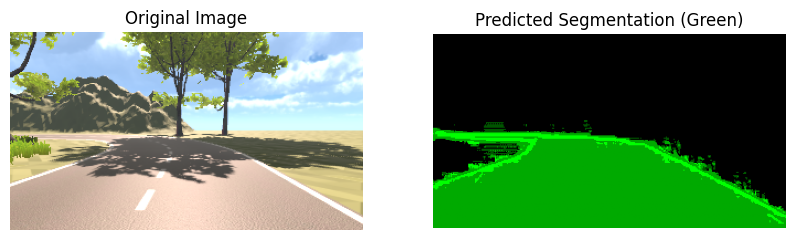

In [5]:
model.load_state_dict(torch.load('3_car.pth'))

# Predict and show result
image_path = r'D:\Demo 1.2\Unet\data\output_raw\0008.png'
predict_and_show(model, image_path, transform, device='cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
import cv2
path = r'D:\Demo 1.2\Unet\dataset\train\output\00000.jpg'
image = cv2.imread(path)
print(image.shape)

(180, 320, 3)
